In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from IPython.display import Image

In [5]:
class IterativeVersion(TypedDict):
    text: str
    version: int
    is_approved: bool

In [12]:
def generate_start_text(IterativeVersion) -> IterativeVersion:
    IterativeVersion['text'] = "This is beginning of the text."
    IterativeVersion['version'] = 1
    return IterativeVersion

def request_next_version(IterativeVersion) -> IterativeVersion:
    IterativeVersion['version'] += 1
    return IterativeVersion

def update_text(IterativeVersion) -> IterativeVersion:
    IterativeVersion['text'] = f"This is version {IterativeVersion['version']} of the text."
    return IterativeVersion

def check_approval(IterativeVersion) -> Literal["needs_improvement", "approved"]:
    if IterativeVersion['version'] >= 3:
        IterativeVersion['is_approved'] = True
        return "approved"
    else:
        IterativeVersion['is_approved'] = False
        return "needs_improvement"

In [13]:
def show_workflow_image(workflow: StateGraph) -> Image:
    return Image(workflow.get_graph().draw_mermaid_png())

In [16]:
# Graph
graph = StateGraph(IterativeVersion)

# Nodes
graph.add_node("generate_start_text", generate_start_text)
graph.add_node("request_next_version", request_next_version)
graph.add_node("update_text", update_text)

# Edges
graph.add_edge(START, "generate_start_text")
graph.add_edge("generate_start_text", "update_text")
graph.add_conditional_edges(
    "update_text", # source
    check_approval, # callable function to tell next node
    { # next node mapping
        "needs_improvement": "request_next_version",
        "approved": END
    }
)
graph.add_edge("request_next_version", "update_text")

In [17]:
workflow = graph.compile()

In [19]:
initial_state = IterativeVersion(text="", version=0, is_approved=False)
final_state = workflow.invoke(initial_state)
print(final_state)

{'text': 'This is version 3 of the text.', 'version': 3, 'is_approved': False}


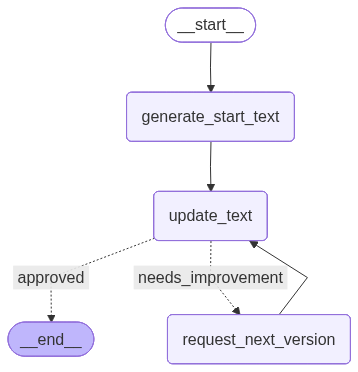

In [18]:
show_workflow_image(workflow)